# **Day 24: Regularisation - Ridge, Lasso and Elastic Net**
*Module 4 - Regression*

With many features, few samples or correlated features, OLS overfits and its coefficients become unstable. **Regularisation** adds a penalty on coefficient size, trading a little bias for a large reduction in variance.

$$\min_{\mathbf w}\;\lVert\mathbf y - X\mathbf w\rVert^2 + \underbrace{\alpha\lVert\mathbf w\rVert_2^2}_{\text{Ridge (L2)}}\qquad\text{or}\qquad + \underbrace{\alpha\lVert\mathbf w\rVert_1}_{\text{Lasso (L1)}}$$

> Regularisation adds a penalty for large coefficients so the model stays simple and generalises better. Ridge shrinks all coefficients, Lasso can set some exactly to zero (feature selection), and Elastic Net mixes both.
>
> *Example:* With 200 spectral features and only 100 field plots, plain regression overfits. Lasso keeps maybe 10 useful bands and drops the rest.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet, RidgeCV, LassoCV, ElasticNetCV, lasso_path
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import cross_val_score, train_test_split
rng = np.random.default_rng(24)

## **1. A Hard Problem: Many Correlated Features, Few Samples**
Simulate a hyperspectral-like problem: 120 narrow bands (neighbouring bands strongly correlated), only 80 samples, and a target (e.g. leaf nitrogen) that depends on a few spectral regions.

In [2]:
n, p = 80, 120
idx = np.arange(p)
corr = 0.95 ** np.abs(np.subtract.outer(idx, idx))
X = rng.normal(size=(n + 1000, p)) @ np.linalg.cholesky(corr).T
w_true = np.zeros(p); w_true[[20, 21, 22]] = 1.0; w_true[[70, 71]] = -1.5; w_true[100] = 0.8
y = X @ w_true + rng.normal(0, 1.0, n + 1000)
X_tr, y_tr, X_te, y_te = X[:n], y[:n], X[n:], y[n:]

def test_r2(model):
    return model.fit(X_tr, y_tr).score(X_te, y_te)

print(f"OLS   test R2: {test_r2(LinearRegression()):.3f}   (p > n: OLS interpolates the training data)")
print(f"Ridge test R2: {test_r2(make_pipeline(StandardScaler(), RidgeCV(alphas=np.logspace(-3, 4, 50)))):.3f}")
print(f"Lasso test R2: {test_r2(make_pipeline(StandardScaler(), LassoCV(cv=5, random_state=0, max_iter=50000))):.3f}")
print(f"ENet  test R2: {test_r2(make_pipeline(StandardScaler(), ElasticNetCV(l1_ratio=[.2, .5, .8, .95], cv=5, random_state=0, max_iter=50000))):.3f}")

OLS   test R2: 0.746   (p > n: OLS interpolates the training data)
Ridge test R2: 0.890
Lasso test R2: 0.924


ENet  test R2: 0.923


## **2. Ridge (L2)**
Closed form: $\hat{\mathbf w}_{ridge} = (X^\top X + \alpha I)^{-1}X^\top\mathbf y$. Adding $\alpha I$ makes the matrix invertible and well-conditioned (Day 7). Ridge **shrinks** all coefficients towards zero but never exactly to zero. It is MAP with a Gaussian prior (Day 14).

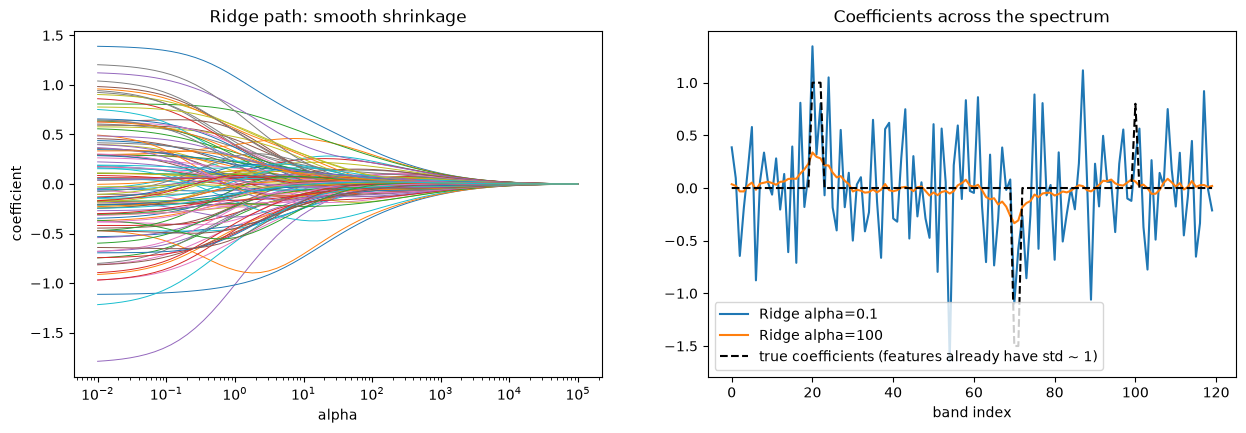

In [3]:
Xs = StandardScaler().fit_transform(X_tr); yc = y_tr - y_tr.mean()
alphas = np.logspace(-2, 5, 60)
coefs = np.array([np.linalg.solve(Xs.T @ Xs + a * np.eye(p), Xs.T @ yc) for a in alphas])
fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))
axes[0].semilogx(alphas, coefs, lw=0.7); axes[0].set(xlabel="alpha", ylabel="coefficient", title="Ridge path: smooth shrinkage")
for a, c in [(0.1, "C0"), (100, "C1")]:
    axes[1].plot(np.linalg.solve(Xs.T @ Xs + a * np.eye(p), Xs.T @ yc), c, label=f"Ridge alpha={a}")
axes[1].plot(w_true, "k--", label="true coefficients (features already have std ~ 1)")
axes[1].set(xlabel="band index", title="Coefficients across the spectrum"); axes[1].legend()
plt.show()

With small $\alpha$ the coefficients oscillate wildly between neighbouring bands (variance). Larger $\alpha$ gives a smooth, stable spectrum.

## **3. Lasso (L1): Sparse Models**
The L1 penalty drives many coefficients **exactly to zero**: built-in feature selection. Good when only a few features matter.

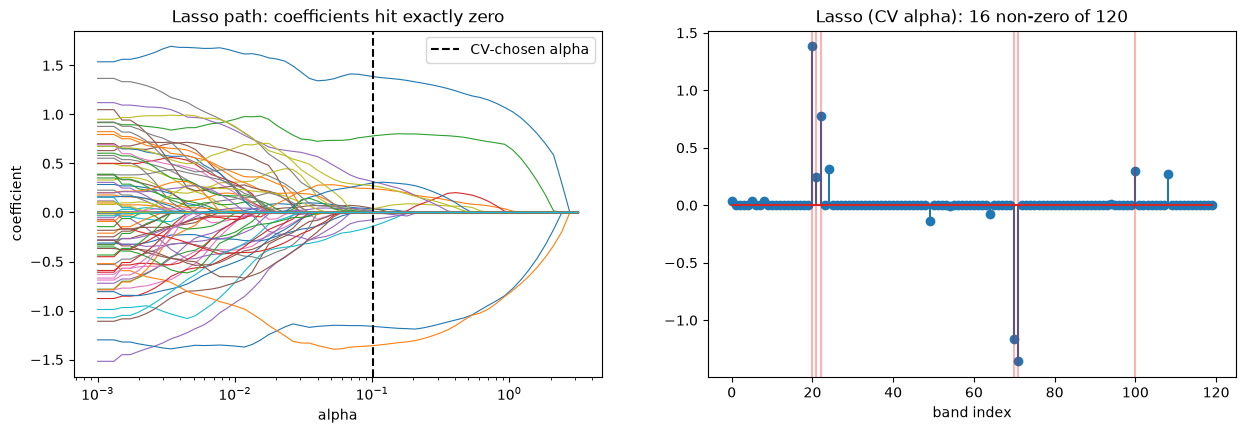

True informative bands: [ 20  21  22  70  71 100]
Lasso-selected bands  : [  0   5   8  20  21  22  24  49  54  64  70  71  94 100 108 117]


In [4]:
lasso_alphas, lasso_coefs, _ = lasso_path(Xs, yc, alphas=np.logspace(-3, 0.5, 60), max_iter=50000)
lcv = LassoCV(cv=5, random_state=0, max_iter=50000).fit(Xs, yc)
fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))
axes[0].semilogx(lasso_alphas, lasso_coefs.T, lw=0.8); axes[0].axvline(lcv.alpha_, c="k", ls="--", label="CV-chosen alpha")
axes[0].set(xlabel="alpha", ylabel="coefficient", title="Lasso path: coefficients hit exactly zero"); axes[0].legend()
axes[1].stem(lcv.coef_); axes[1].set(xlabel="band index", title=f"Lasso (CV alpha): {np.sum(lcv.coef_ != 0)} non-zero of {p}")
for b in np.flatnonzero(w_true):
    axes[1].axvline(b, c="r", alpha=0.3)
plt.show()
print("True informative bands:", np.flatnonzero(w_true))
print("Lasso-selected bands  :", np.flatnonzero(lcv.coef_))

**Lasso's weakness:** among a group of highly correlated features (bands 20, 21, 22), it tends to pick **one** somewhat arbitrarily, and the choice changes between samples.

## **4. Elastic Net**
$\alpha\left[\rho\lVert\mathbf w\rVert_1 + \frac{1-\rho}{2}\lVert\mathbf w\rVert_2^2\right]$ combines sparsity (L1) with the grouping effect of L2: correlated features tend to enter or leave together.

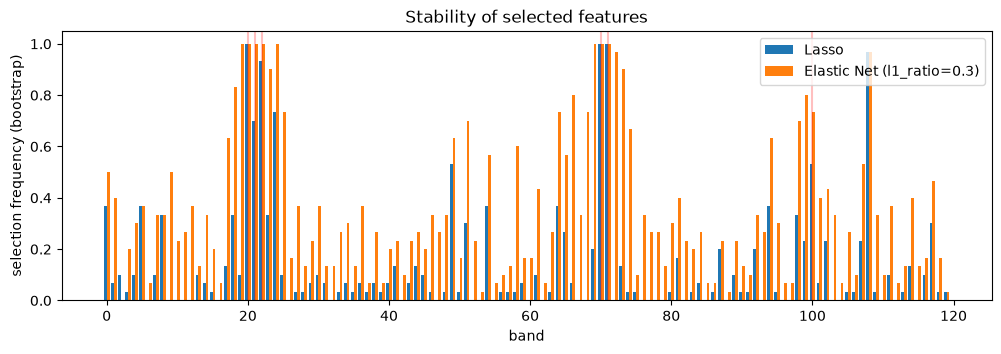

In [5]:
def selection_stability(model, B=30):
    counts = np.zeros(p)
    for b in range(B):
        i = rng.choice(n, n, replace=True)
        m = model.fit(StandardScaler().fit_transform(X_tr[i]), y_tr[i])
        counts += m.coef_ != 0
    return counts / B

stab_l = selection_stability(Lasso(alpha=lcv.alpha_, max_iter=50000))
stab_e = selection_stability(ElasticNet(alpha=lcv.alpha_ * 2, l1_ratio=0.3, max_iter=50000))
plt.figure(figsize=(12, 3.5))
plt.bar(idx - 0.2, stab_l, 0.4, label="Lasso"); plt.bar(idx + 0.2, stab_e, 0.4, label="Elastic Net (l1_ratio=0.3)")
for b in np.flatnonzero(w_true): plt.axvline(b, c="r", alpha=0.25)
plt.xlabel("band"); plt.ylabel("selection frequency (bootstrap)"); plt.legend(); plt.title("Stability of selected features"); plt.show()

## **5. Always Standardise Before Regularising**
The penalty treats all coefficients equally. A feature measured in mm (large numbers, small coefficient) is barely penalised; one measured in metres is heavily penalised. Standardising puts all features on the same footing.

In [6]:
Xu = X_tr.copy(); Xu[:, [70, 71]] *= 0.001          # e.g. a band stored in different units (much smaller numbers)
raw = Lasso(alpha=0.1, max_iter=100000).fit(Xu, y_tr).coef_
scaled = make_pipeline(StandardScaler(), Lasso(alpha=0.1, max_iter=100000)).fit(Xu, y_tr)[-1].coef_
print("Bands 70/71 kept WITHOUT scaling:", raw[[70, 71]] != 0, "-> the needed coefficient is 1000x larger, so the penalty kills it")
print("Bands 70/71 kept WITH scaling   :", scaled[[70, 71]] != 0)

Bands 70/71 kept WITHOUT scaling: [False False] -> the needed coefficient is 1000x larger, so the penalty kills it
Bands 70/71 kept WITH scaling   : [ True  True]


# **Part 2: Going Deeper**

### Geometry: why L1 gives zeros
Penalised regression is equivalent to minimising the loss **subject to** $\lVert\mathbf w\rVert\le t$. The elliptical loss contours first touch the L2 ball (a circle) at a generic point, but they usually touch the L1 ball (a diamond) at a **corner**, where some coordinates are exactly zero.

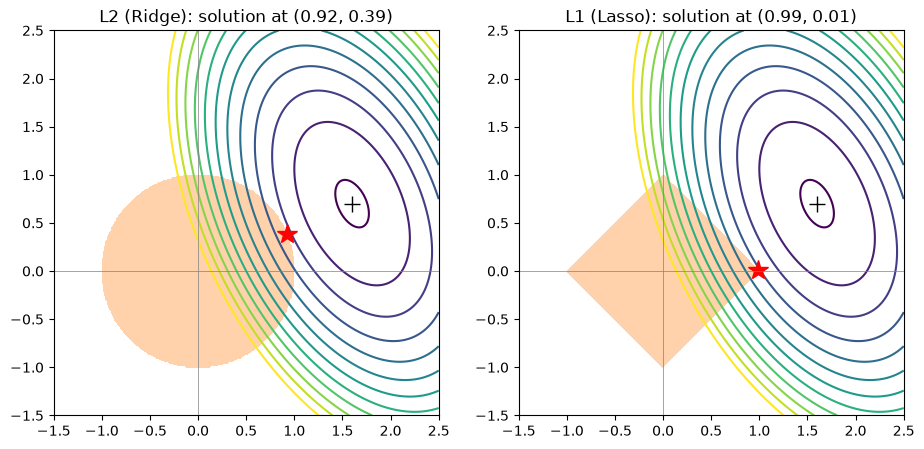

In [7]:
w1, w2 = np.meshgrid(np.linspace(-1.5, 2.5, 300), np.linspace(-1.5, 2.5, 300))
loss = 2 * (w1 - 1.6) ** 2 + (w2 - 0.7) ** 2 + 1.2 * (w1 - 1.6) * (w2 - 0.7)
fig, axes = plt.subplots(1, 2, figsize=(11, 5))
for ax, (name, ball) in zip(axes, [("L2 (Ridge)", np.sqrt(w1 ** 2 + w2 ** 2)), ("L1 (Lasso)", np.abs(w1) + np.abs(w2))]):
    ax.contour(w1, w2, loss, levels=np.linspace(0.05, 6, 12), cmap="viridis")
    ax.contourf(w1, w2, ball <= 1, levels=[0.5, 1.5], colors=["C1"], alpha=0.35)
    feasible = ball <= 1
    k = np.argmin(np.where(feasible, loss, np.inf))
    ax.plot(w1.ravel()[k], w2.ravel()[k], "r*", ms=15); ax.plot(1.6, 0.7, "k+", ms=12)
    ax.set_title(f"{name}: solution at ({w1.ravel()[k]:.2f}, {w2.ravel()[k]:.2f})"); ax.set_aspect("equal"); ax.axhline(0, c="grey", lw=0.5); ax.axvline(0, c="grey", lw=0.5)
plt.show()

### Coordinate descent with soft-thresholding (Lasso from scratch)
Update one coefficient at a time. With standardised features, the exact 1-D minimiser is the **soft-threshold** of the partial-residual correlation:
$$w_j \leftarrow S\!\left(\tfrac{1}{n}\mathbf x_j^\top\mathbf r_{-j},\;\alpha\right),\qquad S(z,\alpha) = \text{sign}(z)\max(|z|-\alpha, 0)$$
(using scikit-learn's objective $\frac{1}{2n}\lVert\mathbf y-X\mathbf w\rVert^2 + \alpha\lVert\mathbf w\rVert_1$).

In [8]:
def soft_threshold(z, a):
    return np.sign(z) * np.maximum(np.abs(z) - a, 0.0)

def lasso_cd(X, y, alpha, n_iter=500):
    n_, p_ = X.shape; w = np.zeros(p_); r = y - X @ w
    col_sq = (X ** 2).sum(0) / n_
    for _ in range(n_iter):
        for j in range(p_):
            r += X[:, j] * w[j]                                    # remove feature j from the fit
            w[j] = soft_threshold(X[:, j] @ r / n_, alpha) / col_sq[j]
            r -= X[:, j] * w[j]
    return w

w_cd = lasso_cd(Xs, yc, alpha=0.1)
w_sk = Lasso(alpha=0.1, fit_intercept=False, max_iter=100000, tol=1e-10).fit(Xs, yc).coef_
print("max |difference| from sklearn:", np.abs(w_cd - w_sk).max().round(6), "| non-zeros:", np.sum(w_cd != 0))

max |difference| from sklearn: 0.0 | non-zeros: 16


### The one-standard-error rule
Choose the **largest** (most regularised, simplest) $\alpha$ whose CV error is within one standard error of the minimum. It often gives a much sparser model with practically equal accuracy.

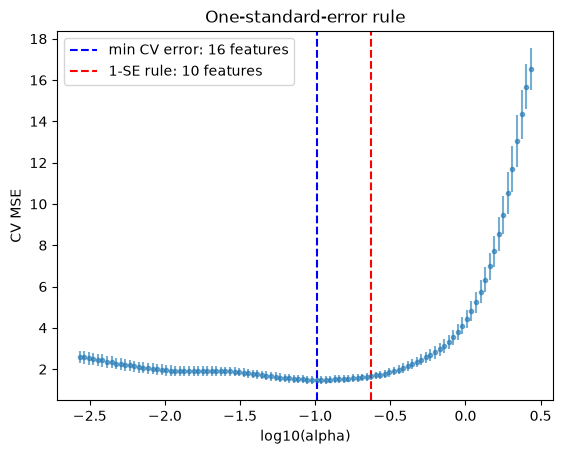

In [9]:
mse_mean = lcv.mse_path_.mean(1); mse_se = lcv.mse_path_.std(1) / np.sqrt(lcv.mse_path_.shape[1])
i_min = mse_mean.argmin(); thresh = mse_mean[i_min] + mse_se[i_min]
alpha_1se = lcv.alphas_[np.where(mse_mean <= thresh)[0].min()]       # alphas_ are sorted descending
m_1se = Lasso(alpha=alpha_1se, max_iter=50000).fit(Xs, yc)
plt.errorbar(np.log10(lcv.alphas_), mse_mean, yerr=mse_se, fmt=".", alpha=0.6)
plt.axvline(np.log10(lcv.alpha_), c="b", ls="--", label=f"min CV error: {np.sum(lcv.coef_ != 0)} features")
plt.axvline(np.log10(alpha_1se), c="r", ls="--", label=f"1-SE rule: {np.sum(m_1se.coef_ != 0)} features")
plt.xlabel("log10(alpha)"); plt.ylabel("CV MSE"); plt.legend(); plt.title("One-standard-error rule"); plt.show()

## **Practice Problems**
1. Use `load_diabetes` and compare OLS, RidgeCV, LassoCV and ElasticNetCV with 10-fold CV R^2.
2. Which diabetes features does Lasso drop at the CV-chosen alpha?
3. Verify the Ridge closed form against `Ridge(alpha=10, fit_intercept=False)` on `Xs, yc`.
4. *(Advanced)* Implement Ridge for $p \gg n$ efficiently using the identity $(X^\top X+\alpha I)^{-1}X^\top = X^\top(XX^\top + \alpha I)^{-1}$ (an $n\times n$ solve instead of $p\times p$).

In [10]:
# Solution 1-2
from sklearn.datasets import load_diabetes
Xd, yd = load_diabetes(return_X_y=True, as_frame=True)
for name, m in {"OLS": LinearRegression(), "RidgeCV": RidgeCV(alphas=np.logspace(-3, 3, 40)),
                "LassoCV": LassoCV(cv=5, random_state=0), "ENetCV": ElasticNetCV(l1_ratio=[.1, .5, .9], cv=5, random_state=0)}.items():
    print(f"{name:<8} CV R2 = {cross_val_score(make_pipeline(StandardScaler(), m), Xd, yd, cv=10).mean():.4f}")
lasso_d = make_pipeline(StandardScaler(), LassoCV(cv=5, random_state=0)).fit(Xd, yd)
print("Dropped by Lasso:", list(Xd.columns[lasso_d[-1].coef_ == 0]))
# Solution 3
print(np.allclose(np.linalg.solve(Xs.T @ Xs + 10 * np.eye(p), Xs.T @ yc), Ridge(alpha=10, fit_intercept=False).fit(Xs, yc).coef_))
# Solution 4
w_dual = Xs.T @ np.linalg.solve(Xs @ Xs.T + 10 * np.eye(n), yc)
print("Dual form matches:", np.allclose(w_dual, Ridge(alpha=10, fit_intercept=False).fit(Xs, yc).coef_))

OLS      CV R2 = 0.4620


RidgeCV  CV R2 = 0.4578


LassoCV  CV R2 = 0.4595


ENetCV   CV R2 = 0.4604
Dropped by Lasso: ['s3']
True
Dual form matches: True


## **Key References**
- Hoerl, A. E., & Kennard, R. W. (1970). Ridge regression: Biased estimation for nonorthogonal problems. *Technometrics*, 12(1), 55-67.
- Tibshirani, R. (1996). Regression shrinkage and selection via the lasso. *Journal of the Royal Statistical Society B*, 58(1), 267-288.
- Zou, H., & Hastie, T. (2005). Regularization and variable selection via the elastic net. *Journal of the Royal Statistical Society B*, 67(2), 301-320.
- Friedman, J., Hastie, T., & Tibshirani, R. (2010). Regularization paths for generalized linear models via coordinate descent. *Journal of Statistical Software*, 33(1), 1-22.
- Hastie, T., Tibshirani, R., & Wainwright, M. (2015). *Statistical Learning with Sparsity*. CRC Press.